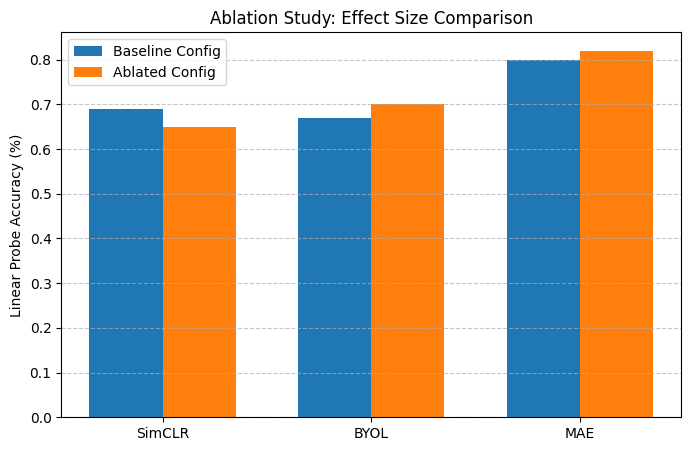

In [1]:
import numpy as np
import matplotlib.pyplot as plt

methods = ['SimCLR', 'BYOL', 'MAE']
baseline_acc = [0.69, 0.67, 0.80]
ablation_acc = [0.65, 0.70, 0.82] 

x = np.arange(len(methods))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, baseline_acc, width, label='Baseline Config')
ax.bar(x + width/2, ablation_acc, width, label='Ablated Config')

ax.set_ylabel('Linear Probe Accuracy (%)')
ax.set_title('Ablation Study: Effect Size Comparison')
ax.set_xticks(x)
ax.set_xticklabels(methods)
ax.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

p-value: 0.00674
          SimCLR      BYOL       MAE
SimCLR  1.000000  0.004464  0.253784
BYOL    0.004464  1.000000  0.253784
MAE     0.253784  0.253784  1.000000


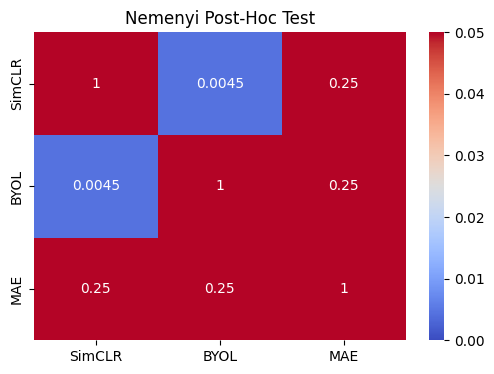

In [2]:
!pip install scikit-posthocs

import numpy as np
import pandas as pd
from scipy.stats import friedmanchisquare
import scikit_posthocs as sp
import seaborn as sns
import matplotlib.pyplot as plt

simclr_folds = [69.77, 70.10, 68.50, 71.20, 69.90]
byol_folds = [65.25, 66.10, 64.80, 67.00, 65.50]
mae_folds = [68.53, 69.10, 67.90, 69.50, 68.20]

stat, p_val = friedmanchisquare(simclr_folds, byol_folds, mae_folds)
print(f"p-value: {p_val:.5f}")

data = np.array([simclr_folds, byol_folds, mae_folds]).T
df = pd.DataFrame(data, columns=['SimCLR', 'BYOL', 'MAE'])

nemenyi_res = sp.posthoc_nemenyi_friedman(df)
print(nemenyi_res)

plt.figure(figsize=(6, 4))
sns.heatmap(nemenyi_res, annot=True, cmap='coolwarm', vmin=0, vmax=0.05)
plt.title('Nemenyi Post-Hoc Test')
plt.show()